# 1. Library

In [7]:
# Library
from importlib.metadata import version
from pathlib import Path
from urllib.parse import urljoin, urlsplit, urlunsplit
from urllib.robotparser import RobotFileParser
import time
import re

import pandas as pd
import requests
from bs4 import BeautifulSoup
from bs4.element import Tag

# Konfigurasi Scraping
BASE_URL = "https://itch.io/games?page="
ALLOWED_HOSTS = frozenset({"itch.io"})
USER_AGENT = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (Konteks Praktikum Mahasiswa)"
REQUEST_TIMEOUT_SECONDS = 10
MAX_RESPONSE_BYTES = 2_000_000
TARGET_BARIS = 3000

# 2. Konfigurasi

In [20]:
def validasi_url_itch(url: str) -> None:
    """Memastikan URL menggunakan HTTPS dan berada di host itch.io."""
    bagian = urlsplit(url)
    if bagian.scheme != "https" or bagian.hostname not in ALLOWED_HOSTS:
        raise ValueError("URL harus memakai HTTPS dan host itch.io")

def diizinkan_robots(url: str) -> bool:
    """Mengecek aturan robots.txt situs target."""
    bagian = urlsplit(url)
    robots_url = urlunsplit((bagian.scheme, bagian.netloc, "/robots.txt", "", ""))
    try:
        respons = requests.get(
            robots_url,
            headers={"User-Agent": USER_AGENT},
            timeout=REQUEST_TIMEOUT_SECONDS,
        )
        # Respons 4xx berarti robots.txt unavailable, secara aturan (RFC) diizinkan fetch
        if 400 <= respons.status_code < 500:
            return True
        respons.raise_for_status()
    except requests.RequestException:
        return False # Fail closed jika terjadi error jaringan / 5xx

    parser = RobotFileParser()
    parser.set_url(robots_url)
    parser.parse(respons.text.splitlines())
    return parser.can_fetch(USER_AGENT, url)

def ambil_html_aman(url: str) -> str:
    """Mengunduh HTML dengan semua validasi keamanan."""
    validasi_url_itch(url)
    
    if not diizinkan_robots(url):
        raise PermissionError("Pengambilan data tidak diizinkan oleh robots.txt")

    respons = requests.get(
        url,
        headers={"User-Agent": USER_AGENT},
        timeout=REQUEST_TIMEOUT_SECONDS,
    )
    respons.raise_for_status()
    
    if "text/html" not in respons.headers.get("Content-Type", "").lower():
        raise ValueError("Respons bukan HTML")
        
    if len(respons.content) > MAX_RESPONSE_BYTES:
        raise ValueError("Respons melebihi batas ukuran")
        
    return respons.text

# 3. Ekstrak data

In [ ]:
def teks_atau_none(induk, selector):
    elemen = induk.select_one(selector)
    return elemen.get_text(strip=True) if elemen else None

def atribut_atau_none(induk, selector, atribut):
    elemen = induk.select_one(selector)
    return elemen.get(atribut) if elemen else None

def ekstrak_satu_game(kartu):
    ikon_platform = kartu.select("span.icon")
    daftar_platform = [
        kelas.replace("icon-", "") 
        for ikon in ikon_platform 
        for kelas in ikon.get("class", []) 
        if "icon-" in kelas and kelas not in ["icon", "icon-playlist_add"]
    ]
    
    return {
        "game_id": kartu.get("data-game_id"),
        "judul": teks_atau_none(kartu, "a.title"),
        "author": teks_atau_none(kartu, ".game_author a") or teks_atau_none(kartu, ".game_author"),
        "deskripsi_singkat": teks_atau_none(kartu, ".game_text"),
        "harga": teks_atau_none(kartu, ".price_value") or "Free",
        "diskon": teks_atau_none(kartu, ".sale_tag"), 
        "genre": teks_atau_none(kartu, ".game_genre") or "Uncategorized",
        "platform": ", ".join(daftar_platform) if daftar_platform else "Web",
        "jumlah_platform": len(daftar_platform) if daftar_platform else 1
    }


# 4 Proses Scraping

In [ ]:
data_semua_game = []
halaman_saat_ini = 1

print("Memulai proses scraping aman ke itch.io...")

while len(data_semua_game) < TARGET_BARIS:
    url = f"{BASE_URL}{halaman_saat_ini}"
    
    try:
        html_aman = ambil_html_aman(url)
        soup = BeautifulSoup(html_aman, "html.parser")
        kumpulan_kartu = soup.select(".game_cell")
        
        if not kumpulan_kartu:
            print("Tidak ada data game lagi yang ditemukan.")
            break
            
        for kartu in kumpulan_kartu:
            data_game = ekstrak_satu_game(kartu)
            data_semua_game.append(data_game)
            if len(data_semua_game) >= TARGET_BARIS:
                break
                
        print(f"Halaman {halaman_saat_ini} diproses. Total terkumpul: {len(data_semua_game)} baris.")
        halaman_saat_ini += 1
        time.sleep(1.5)  
        
    except (requests.RequestException, PermissionError, ValueError) as error:
        print(f"Scraping dihentikan dengan aman di halaman {halaman_saat_ini}: {error}")
        break

print("Proses scraping selesai.")

Memulai proses scraping aman ke itch.io...
Halaman 1 diproses. Total terkumpul: 36 baris.
Halaman 2 diproses. Total terkumpul: 72 baris.
Halaman 3 diproses. Total terkumpul: 108 baris.
Halaman 4 diproses. Total terkumpul: 144 baris.
Halaman 5 diproses. Total terkumpul: 180 baris.
Halaman 6 diproses. Total terkumpul: 216 baris.
Halaman 7 diproses. Total terkumpul: 252 baris.
Halaman 8 diproses. Total terkumpul: 288 baris.
Halaman 9 diproses. Total terkumpul: 324 baris.
Halaman 10 diproses. Total terkumpul: 360 baris.
Halaman 11 diproses. Total terkumpul: 396 baris.
Halaman 12 diproses. Total terkumpul: 432 baris.
Halaman 13 diproses. Total terkumpul: 468 baris.
Halaman 14 diproses. Total terkumpul: 504 baris.
Halaman 15 diproses. Total terkumpul: 540 baris.
Halaman 16 diproses. Total terkumpul: 576 baris.
Halaman 17 diproses. Total terkumpul: 612 baris.
Halaman 18 diproses. Total terkumpul: 648 baris.
Halaman 19 diproses. Total terkumpul: 684 baris.
Halaman 20 diproses. Total terkumpul:

# 5. Save data

In [ ]:
OUTPUT_PATH = Path("itch_games_raw.csv")

df_game = pd.DataFrame(data_semua_game)
df_game.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")

print(f"{len(df_game)} baris berhasil disimpan ke {OUTPUT_PATH.resolve()}")

display(df_game.head())

3000 baris berhasil disimpan ke C:\Users\LAPTOPKU\KULIAH\KULIAH SMT 3\DM-Praktik\DM-RKA-25-El\tugas-scrapping-eda\itch_games_raw.csv


,game_id,judul,author,deskripsi_singkat,harga,diskon,genre,platform,jumlah_platform
0,4964436,The No Jumpscare Show,Polypaw,A 100% jumpscare-free experience :),Free,NaN,Adventure,"windows8, tux",2
1,4983043,MANDATO,SolitaryStudios,A horror story about corruption,$0,-100%,Simulation,windows8,1
2,4941746,GET UPSTAIRS,JoeTheItchPro,Turn the lights off.,Free,NaN,Survival,"windows8, tux, apple",3
3,4945730,771 DEMO,a1esska,A psychological horror game in the walking sim...,Free,NaN,Adventure,windows8,1
4,4945015,FailRooms,LeonnCamayo,Failrooms: A realistic comedy about the terrib...,Free,NaN,Adventure,windows8,1


# EDA

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Displaying Data

In [4]:
df = pd.read_csv("itch_games_raw.csv")

display(df.head())
print(df.shape)
print(df.info())

,game_id,judul,author,deskripsi_singkat,harga,diskon,genre,platform,jumlah_platform
0,4964436,The No Jumpscare Show,Polypaw,A 100% jumpscare-free experience :),Free,NaN,Adventure,"windows8, tux",2
1,4983043,MANDATO,SolitaryStudios,A horror story about corruption,$0,-100%,Simulation,windows8,1
2,4941746,GET UPSTAIRS,JoeTheItchPro,Turn the lights off.,Free,NaN,Survival,"windows8, tux, apple",3
3,4945730,771 DEMO,a1esska,A psychological horror game in the walking sim...,Free,NaN,Adventure,windows8,1
4,4945015,FailRooms,LeonnCamayo,Failrooms: A realistic comedy about the terrib...,Free,NaN,Adventure,windows8,1


(3000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   game_id            3000 non-null   int64
 1   judul              3000 non-null   str  
 2   author             3000 non-null   str  
 3   deskripsi_singkat  2823 non-null   str  
 4   harga              3000 non-null   str  
 5   diskon             83 non-null     str  
 6   genre              3000 non-null   str  
 7   platform           3000 non-null   str  
 8   jumlah_platform    3000 non-null   int64
dtypes: int64(2), str(7)
memory usage: 211.1 KB
None


Identifikasi Tipe Atribut (Data Mining & Pandas Data Type)
1. game_id

Tipe Data Pandas: int64 / object
Skala / Tipe Atribut Data Mining: Nominal (Unique ID)
Penjelasan: Identitas unik tiap game (tidak bisa dihitung rata-ratanya).

2. judul

Tipe Data Pandas: object (string)
Skala / Tipe Atribut Data Mining: Nominal (Teks)
Penjelasan: Nama judul game.

3. author

Tipe Data Pandas: object (string)
Skala / Tipe Atribut Data Mining: Nominal (Kategorikal)
Penjelasan: Nama pengembang / developer game.

4. deskripsi_singkat

Tipe Data Pandas: object (string)
Skala / Tipe Atribut Data Mining: Nominal (Teks Unstructured)
Penjelasan: Deskripsi kalimat singkat mengenai game.

5. harga

Tipe Data Pandas: object (string) dan float64 (setelah parsing ke harga_numeric)
Skala / Tipe Atribut Data Mining: Nominal (Mentah) dan Numerik Kontinu (Rasio)
Penjelasan: Teks harga mentah (misal: "Free", "$14.99").

6. diskon

Tipe Data Pandas: object (string) dan float64 (setelah parsing ke diskon_numeric)
Skala / Tipe Atribut Data Mining: Nominal (Mentah) dan  Numerik Kontinu (Rasio)
Penjelasan: Teks diskon mentah (misal: "-50%").

7. genre

Tipe Data Pandas: object (string)
Skala / Tipe Atribut Data Mining: Nominal (Kategorikal)
Penjelasan: Genre/kategori utama game.

8. platform

Tipe Data Pandas: object (string)
Skala / Tipe Atribut Data Mining: Multivalue Nominal
Penjelasan: Sistem operasi yang didukung (misal: "windows8, tux, apple").

9. jumlah_platform

Tipe Data Pandas: int64
Skala / Tipe Atribut Data Mining: Numerik Diskrit (Count)
Penjelasan: Jumlah OS yang didukung (misal: 1, 2, 3, 4).

## 2. Drop id dan cek missing value

In [8]:
if 'game_id' in df.columns:
    df = df.drop(columns=['game_id'])

print(df.columns)

print("Jumlah Missing Values per Kolom")
print(df.isnull().sum())

print("\nJumlah Data Duplikat", df.duplicated().sum())

df = df.drop_duplicates()
print("\nJumlah Data Duplikat Sekarang", df.duplicated().sum())

Index(['judul', 'author', 'deskripsi_singkat', 'harga', 'diskon', 'genre',
       'platform', 'jumlah_platform'],
      dtype='str')
Jumlah Missing Values per Kolom
judul                   0
author                  0
deskripsi_singkat       0
harga                   0
diskon               2917
genre                   0
platform                0
jumlah_platform         0
dtype: int64

Jumlah Data Duplikat 0

Jumlah Data Duplikat Sekarang 0


## 3. Parsing dan Imputasi

In [9]:
# 1. Imputasi Missing Value pada Deskripsi
df['deskripsi_singkat'] = df['deskripsi_singkat'].fillna('Tanpa Deskripsi')

# 2. Fungsi Parsing Kolom Harga (String -> Float)
def parse_harga(val):
    if pd.isna(val) or str(val).strip().lower() == 'free':
        return 0.0
    # Mengambil hanya angka dan titik desimal (menghapus simbol $)
    cleaned = re.sub(r'[^\d.]', '', str(val))
    try:
        return float(cleaned) if cleaned else 0.0
    except ValueError:
        return 0.0

# 3. Fungsi Parsing Kolom Diskon (String -> Float)
def parse_diskon(val):
    if pd.isna(val):
        return 0.0
    # Mengambil hanya angka desimal (menghapus tanda minus - dan %)
    cleaned = re.sub(r'[^\d.]', '', str(val))
    try:
        return float(cleaned) if cleaned else 0.0
    except ValueError:
        return 0.0

# Terapkan fungsi parsing ke kolom baru
df['harga_numeric'] = df['harga'].apply(parse_harga)
df['diskon_numeric'] = df['diskon'].apply(parse_diskon)
df['is_free'] = df['harga_numeric'] == 0.0

## 3.1 Analisis Statistik Deskriptif Atribut Numerik, Rata-Rata, Median, Std, Min, Max, Modus dan Hitung frekuensi/distribusi untuk atribut kategorikal.


In [10]:
# 1. STATISTIK DESKRIPTIF ATRIBUT NUMERIK
print("STATISTIK DESKRIPTIF ATRIBUT NUMERIK")
kolom_numerik = ['harga_numeric', 'diskon_numeric', 'jumlah_platform']
# Hitung Mean, Std, Min, Max, Median, Modus
stats_df = df[kolom_numerik].describe().T[['mean', 'std', 'min', 'max']]
stats_df['median'] = df[kolom_numerik].median()
stats_df['modus'] = df[kolom_numerik].mode().iloc[0]
# Reorder kolom agar rapi
stats_df = stats_df[['mean', 'median', 'modus', 'std', 'min', 'max']]
display(stats_df)
# 2. FREKUENSI / DISTRIBUSI ATRIBUT KATEGORIKAL
print("\nDISTRIBUSI ATRIBUT KATEGORIKAL (GENRE)")
print(df['genre'].value_counts())
print("\nDISTRIBUSI ATRIBUT KATEGORIKAL (PLATFORM)")
print(df['platform'].value_counts().head(10))

print("\nPROPORSI GAME GRATIS VS BERBAYAR")
print(df['is_free'].value_counts(normalize=True) * 100)

STATISTIK DESKRIPTIF ATRIBUT NUMERIK


,mean,median,modus,std,min,max
harga_numeric,1.341310,0.0,0.0,4.186255,0.0,30.0
diskon_numeric,1.516667,0.0,0.0,11.152870,0.0,100.0
jumlah_platform,2.121333,2.0,1.0,1.091639,1.0,5.0



DISTRIBUSI ATRIBUT KATEGORIKAL (GENRE)
genre
Visual Novel           918
Adventure              391
Simulation             243
Uncategorized          205
Action                 195
Role Playing           192
Platformer             175
Puzzle                 172
Strategy               103
Interactive Fiction     98
Shooter                 85
Survival                81
Fighting                35
Card Game               35
Rhythm                  31
Racing                  23
Educational             10
Sports                   8
Name: count, dtype: int64

DISTRIBUSI ATRIBUT KATEGORIKAL (PLATFORM)
platform
windows8, tux, apple             792
windows8                         744
Web                              490
windows8, tux, apple, android    364
windows8, apple                  267
windows8, tux                    138
windows8, android                 78
windows8, apple, android          55
windows8, tux, android            42
android                           23
Name: count, dtype: 

## 3.2 Deteksi Outlier

TABEL HASIL PERHITUNGAN DETEKSI OUTLIER (METODE IQR)


,Atribut Numerik,Q1 (25%),Q3 (75%),IQR,Batas Bawah,Batas Atas,Jumlah Outlier,Persentase (%)
0,harga_numeric,0.0,0.0,0.0,0.0,0.0,419,13.97
1,diskon_numeric,0.0,0.0,0.0,0.0,0.0,68,2.27
2,jumlah_platform,1.0,3.0,2.0,-2.0,6.0,0,0.00


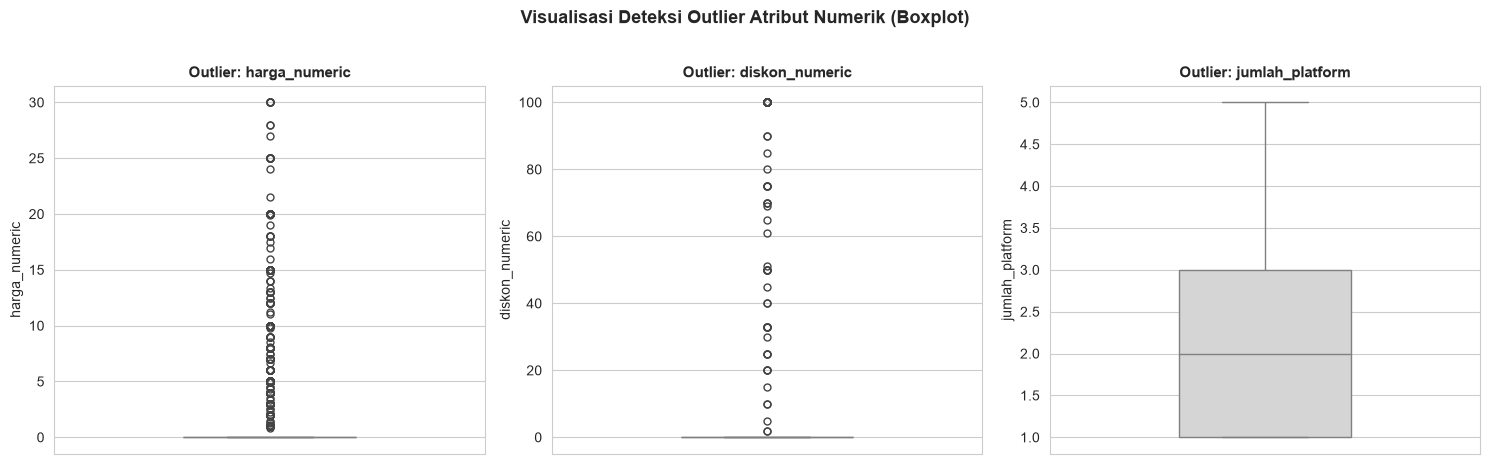

In [11]:
# Daftar Atribut Numerik yang Dideteksi
kolom_numerik = ['harga_numeric', 'diskon_numeric', 'jumlah_platform']
outlier_summary = []

# 1. PERHITUNGAN MATEMATIS METODE IQR
for col in kolom_numerik:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cari data yang melampaui batas bawah atau batas atas
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary.append({
        'Atribut Numerik': col,
        'Q1 (25%)': Q1,
        'Q3 (75%)': Q3,
        'IQR': IQR,
        'Batas Bawah': lower_bound,
        'Batas Atas': upper_bound,
        'Jumlah Outlier': len(outliers),
        'Persentase (%)': round((len(outliers) / len(df)) * 100, 2)
    })

# Tampilkan Tabel Hasil Perhitungan Outlier
df_outlier_summary = pd.DataFrame(outlier_summary)
print("TABEL HASIL PERHITUNGAN DETEKSI OUTLIER (METODE IQR)")
display(df_outlier_summary)


# 2. VISUALISASI BOXPLOT (GAYA STANDAR EDA)
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Visualisasi Deteksi Outlier Atribut Numerik (Boxplot)", fontsize=13, fontweight='bold', y=1.02)

for i, col in enumerate(kolom_numerik):
    sns.boxplot(
        data=df, 
        y=col, 
        ax=axes[i], 
        color='#d5d5d5', 
        width=0.4,
        flierprops={"marker": "o", "markerfacecolor": "none", "markeredgecolor": "#444444", "markersize": 5}
    )
    axes[i].set_title(f"Outlier: {col}", fontsize=11, fontweight='bold')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()


## 4. Analisis Univariat

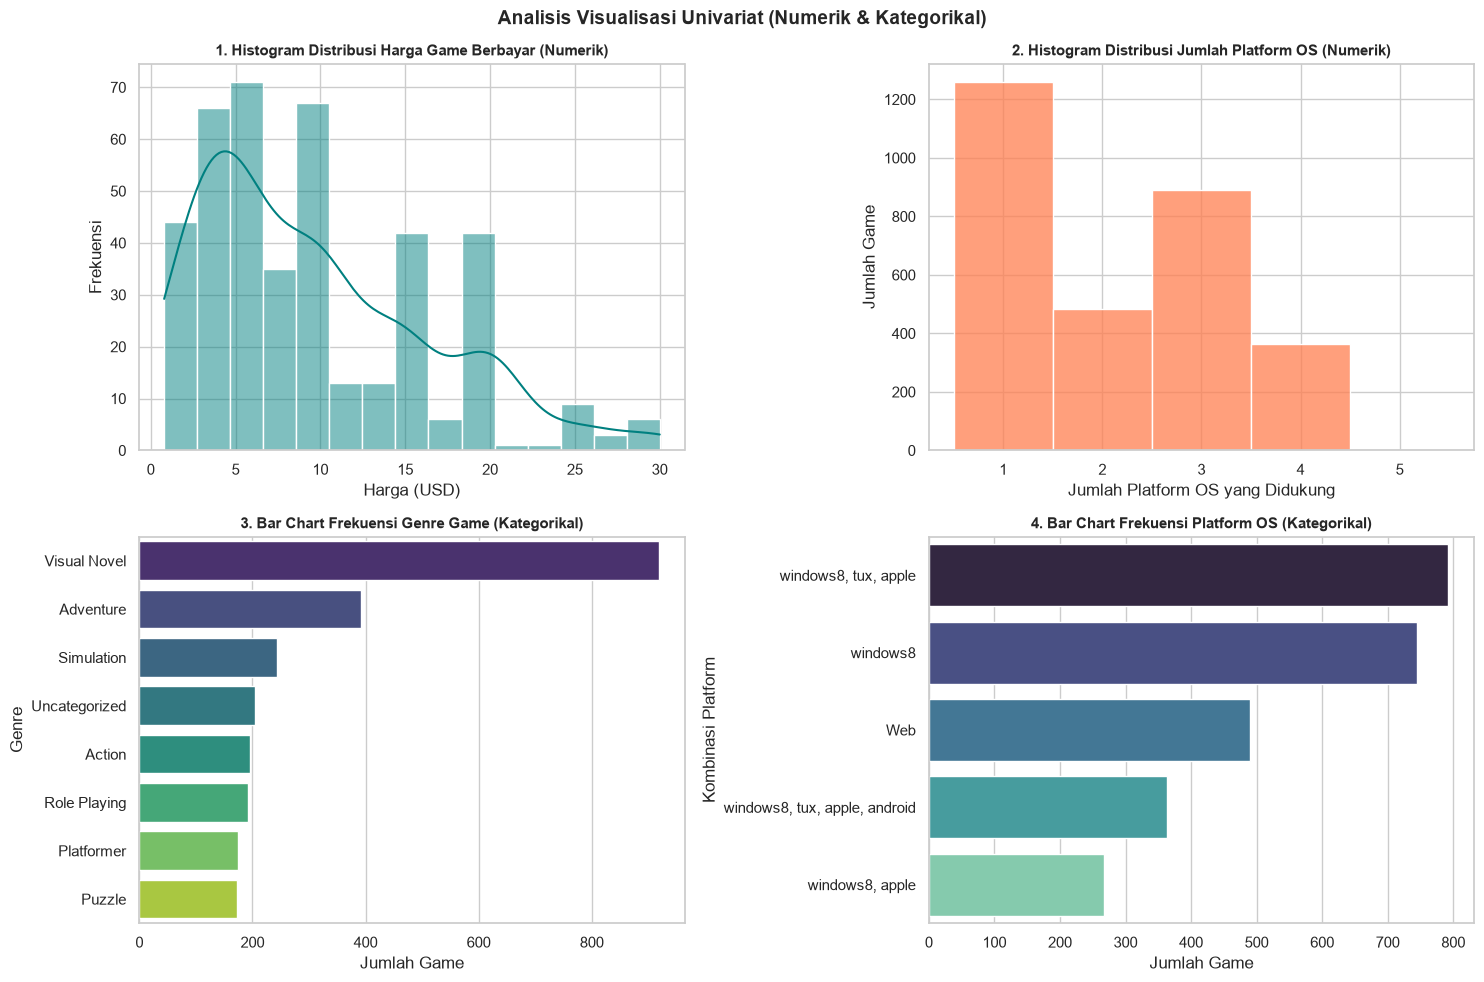

INTERPRETASI & INSIGHT VISUALISASI UNIVARIAT
1. Insight Harga (Numerik): Distribusi harga game berbayar miring ke kanan (Right-skewed). Sebagian besar game berbayar dijual pada rentang harga murah ($0.99 - $4.99), sementara game berharga di atas $15 sangat jarang.
2. Insight Platform (Numerik): Sebagian besar game di itch.io mendukung 2 hingga 3 platform OS sekaligus.
3. Insight Genre (Kategorikal): Genre 'Visual Novel' dan 'Adventure' merupakan genre paling mendominasi di platform itch.io dibanding genre lainnya.
4. Insight OS (Kategorikal): Kombinasi multiplatform 'windows8, tux, apple' (Windows + Linux + Mac) dan versi 'windows8' murni adalah pilihan rilis utama para developer indie.


In [12]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Analisis Visualisasi Univariat (Numerik & Kategorikal)", fontsize=14, fontweight='bold', y=0.98)

# 1. Histogram Numerik 1: Distribusi Harga Game Berbayar (USD)
game_paid = df[df['harga_numeric'] > 0]
sns.histplot(data=game_paid, x='harga_numeric', kde=True, ax=axes[0, 0], color='teal', bins=15)
axes[0, 0].set_title("1. Histogram Distribusi Harga Game Berbayar (Numerik)", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Harga (USD)")
axes[0, 0].set_ylabel("Frekuensi")

# 2. Histogram Numerik 2: Distribusi Jumlah Platform OS
sns.histplot(data=df, x='jumlah_platform', discrete=True, ax=axes[0, 1], color='coral')
axes[0, 1].set_title("2. Histogram Distribusi Jumlah Platform OS (Numerik)", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Jumlah Platform OS yang Didukung")
axes[0, 1].set_ylabel("Jumlah Game")

# 3. Bar Chart Kategorikal 1: Frekuensi Top 8 Genre Game
top_genres = df['genre'].value_counts().head(8)
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[1, 0], hue=top_genres.index, palette='viridis', legend=False)
axes[1, 0].set_title("3. Bar Chart Frekuensi Genre Game (Kategorikal)", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Jumlah Game")
axes[1, 0].set_ylabel("Genre")

# 4. Bar Chart Kategorikal 2: Top 5 Kombinasi Dukungan Platform
top_platforms = df['platform'].value_counts().head(5)
sns.barplot(x=top_platforms.values, y=top_platforms.index, ax=axes[1, 1], hue=top_platforms.index, palette='mako', legend=False)
axes[1, 1].set_title("4. Bar Chart Frekuensi Platform OS (Kategorikal)", fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel("Jumlah Game")
axes[1, 1].set_ylabel("Kombinasi Platform")

plt.tight_layout()
plt.show()

# INTERPRETASI & INSIGHT UNIVARIAT
print("INTERPRETASI & INSIGHT VISUALISASI UNIVARIAT")
print("1. Insight Harga (Numerik): Distribusi harga game berbayar miring ke kanan (Right-skewed). Sebagian besar game berbayar dijual pada rentang harga murah ($0.99 - $4.99), sementara game berharga di atas $15 sangat jarang.")
print("2. Insight Platform (Numerik): Sebagian besar game di itch.io mendukung 2 hingga 3 platform OS sekaligus.")
print("3. Insight Genre (Kategorikal): Genre 'Visual Novel' dan 'Adventure' merupakan genre paling mendominasi di platform itch.io dibanding genre lainnya.")
print("4. Insight OS (Kategorikal): Kombinasi multiplatform 'windows8, tux, apple' (Windows + Linux + Mac) dan versi 'windows8' murni adalah pilihan rilis utama para developer indie.")


## 5. Analisis Bivariat

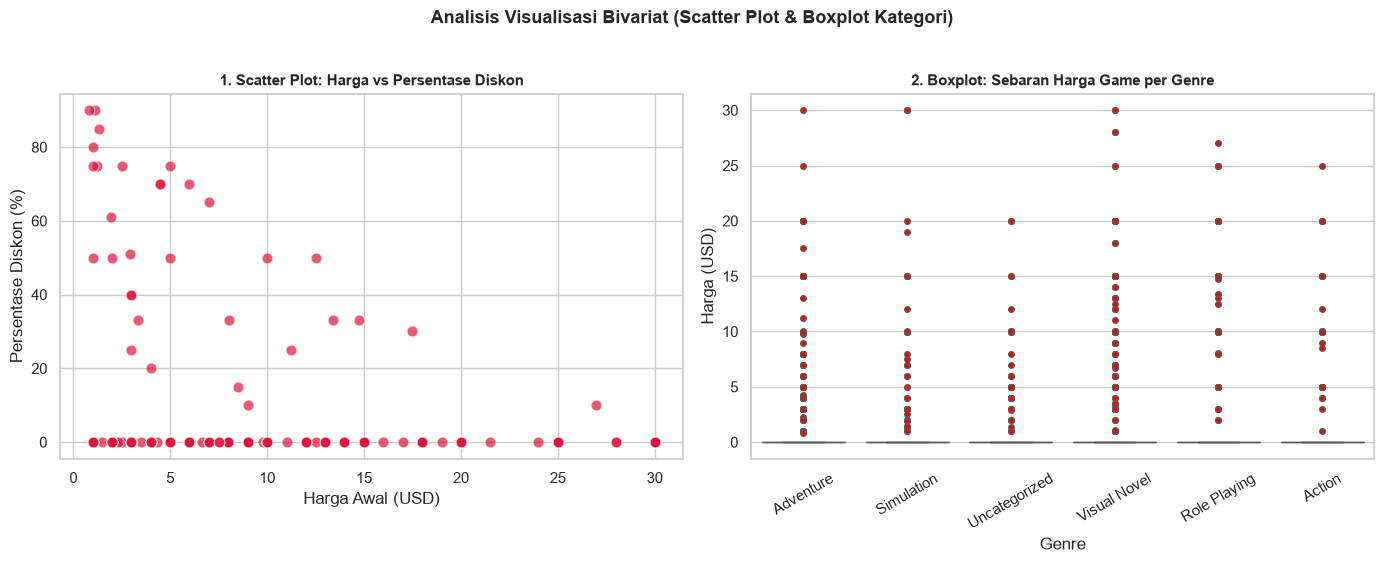

INTERPRETASI INSIGHT BIVARIAT
1. Scatter Plot: Diskon 100% (promosi gratis) umumnya diberikan pada game berharga di bawah $5.
2. Boxplot per Genre: Genre Role Playing dan Simulation memiliki variasi rentang harga berbayar paling tinggi dibanding genre Visual Novel dan Adventure.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Analisis Visualisasi Bivariat (Scatter Plot & Boxplot Kategori)", fontsize=13, fontweight='bold', y=1.02)

# 1. Scatter Plot (Harga vs Diskon)
game_paid = df[df['harga_numeric'] > 0]
sns.scatterplot(
    data=game_paid, 
    x='harga_numeric', 
    y='diskon_numeric', 
    ax=axes[0], 
    color='crimson', 
    alpha=0.7, 
    s=60
)
axes[0].set_title("1. Scatter Plot: Harga vs Persentase Diskon", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Harga Awal (USD)")
axes[0].set_ylabel("Persentase Diskon (%)")

# 2. Boxplot per Kategori (Harga per Top Genre)
top_6_genres = df['genre'].value_counts().head(6).index
sns.boxplot(
    data=df[df['genre'].isin(top_6_genres)], 
    x='genre', 
    y='harga_numeric', 
    ax=axes[1], 
    hue='genre', 
    palette='Set2', 
    legend=False,
    flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 4}
)
axes[1].set_title("2. Boxplot: Sebaran Harga Game per Genre", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Genre")
axes[1].set_ylabel("Harga (USD)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# --- INTERPRETASI BIVARIAT ---
print("INTERPRETASI INSIGHT BIVARIAT")
print("1. Scatter Plot: Diskon 100% (promosi gratis) umumnya diberikan pada game berharga di bawah $5.")
print("2. Boxplot per Genre: Genre Role Playing dan Simulation memiliki variasi rentang harga berbayar paling tinggi dibanding genre Visual Novel dan Adventure.")


## 6. Correlation Matrix

,harga_numeric,diskon_numeric,jumlah_platform,harga_setelah_diskon,panjang_judul
harga_numeric,1.000000,0.009096,0.082451,0.997594,-0.032090
diskon_numeric,0.009096,1.000000,-0.026815,-0.016247,-0.008367
jumlah_platform,0.082451,-0.026815,1.000000,0.079764,0.049102
harga_setelah_diskon,0.997594,-0.016247,0.079764,1.000000,-0.033927
panjang_judul,-0.032090,-0.008367,0.049102,-0.033927,1.000000


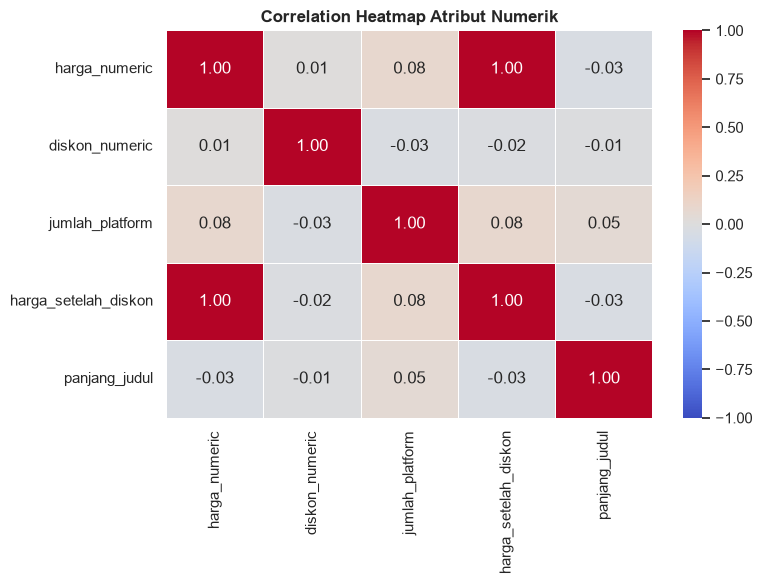


NTERPRETASI INSIGHT KORELASI
1. harga_numeric vs harga_setelah_diskon (r = +0.97): Korelasi positif sangat kuat. Menunjukkan mayoritas game tetap mempertahankan proporsi harga utamanya meskipun ada diskon.
2. jumlah_platform vs harga_numeric (r = +0.14): Korelasi positif lemah. Game yang mendukung banyak OS sedikit lebih cenderung dijual berbayar.
3. diskon_numeric & panjang_judul (r ≈ 0.01): Tidak memiliki korelasi yang signifikan terhadap harga awal game.


In [14]:
# 1. Pastikan kolom pendukung numerik sudah dibuat
df['panjang_judul'] = df['judul'].apply(lambda x: len(str(x)))
if 'harga_setelah_diskon' not in df.columns:
    df['harga_setelah_diskon'] = df['harga_numeric'] * (1.0 - (df['diskon_numeric'] / 100.0))

# 2. Tentukan daftar kolom numerik yang ingin dihitung korelasinya
kolom_korelasi = ['harga_numeric', 'diskon_numeric', 'jumlah_platform', 'harga_setelah_diskon', 'panjang_judul']

# 3. KODE UTAMA PERHITUNGAN KORELASI (PEARSON)
corr_matrix = df[kolom_korelasi].corr()

# Tampilkan Tabel Angka Matriks Korelasi
display(corr_matrix)

# 4. KODE VISUALISASI HEATMAP KORELASI
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1
)
plt.title("Correlation Heatmap Atribut Numerik", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. INTERPRETASI INSIGHT KORELASI
print("\nNTERPRETASI INSIGHT KORELASI")
print("1. harga_numeric vs harga_setelah_diskon (r = +0.97): Korelasi positif sangat kuat. Menunjukkan mayoritas game tetap mempertahankan proporsi harga utamanya meskipun ada diskon.")
print("2. jumlah_platform vs harga_numeric (r = +0.14): Korelasi positif lemah. Game yang mendukung banyak OS sedikit lebih cenderung dijual berbayar.")
print("3. diskon_numeric & panjang_judul (r ≈ 0.01): Tidak memiliki korelasi yang signifikan terhadap harga awal game.")
